In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
df = pd.read_csv("/content/zomato.csv", encoding = "latin-1")

In [17]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [20]:
df.shape

(9551, 21)

In [21]:
# Remove duplicates
df.drop_duplicates(inplace = True)

In [22]:
# Missing values
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [24]:
# Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].mode()[0]
    else:
        df[col] = df[col].median()

In [9]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [25]:
# Dataset overview
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:  9551
Columns:  21


In [26]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9551.0,9551.0,9.551000e+03,9.551000e+03,9551.0,9551.0,9.551000e+03,9551.0
mean,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0
std,0.0,0.0,6.395219e-13,2.884955e-12,0.0,0.0,4.978501e-13,0.0
min,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0
25%,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0
50%,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0
75%,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0
max,6004089.0,1.0,7.719196e+01,2.857047e+01,400.0,2.0,3.200000e+00,31.0


In [32]:
# Does online delivery affect ratings?
df.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,3.2


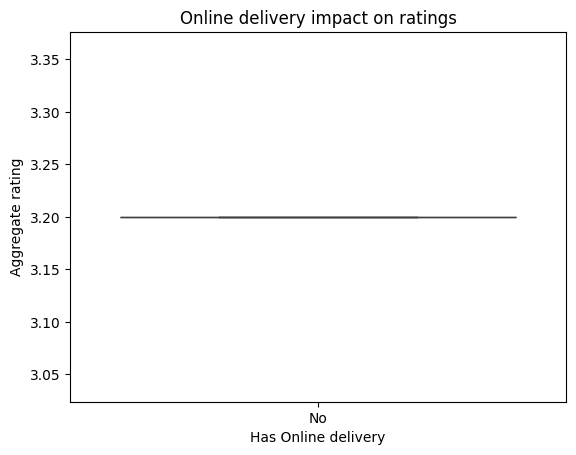

In [33]:
sns.boxplot(data = df,
            x = 'Has Online delivery',
            y = 'Aggregate rating'
            )

plt.title('Online delivery impact on ratings')
plt.show()

In [34]:
# Does Table Booking affect Ratings?
df.groupby('Has Table booking')['Aggregate rating'].mean()

,Aggregate rating
Has Table booking,
No,3.2


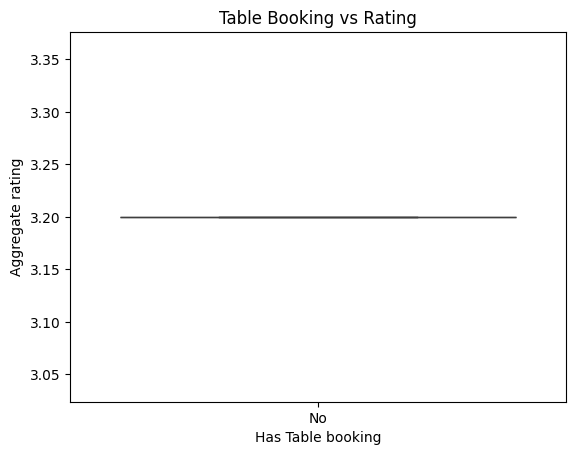

In [35]:
sns.boxplot(
    data=df,
    x='Has Table booking',
    y='Aggregate rating'
)

plt.title("Table Booking vs Rating")
plt.show()

In [36]:
# Which cities have the highest ratings?
city_rating = df.groupby('City')['Aggregate rating'].mean()

print(city_rating.sort_values(ascending = False).head(10))

City
New Delhi    3.2
Name: Aggregate rating, dtype: float64


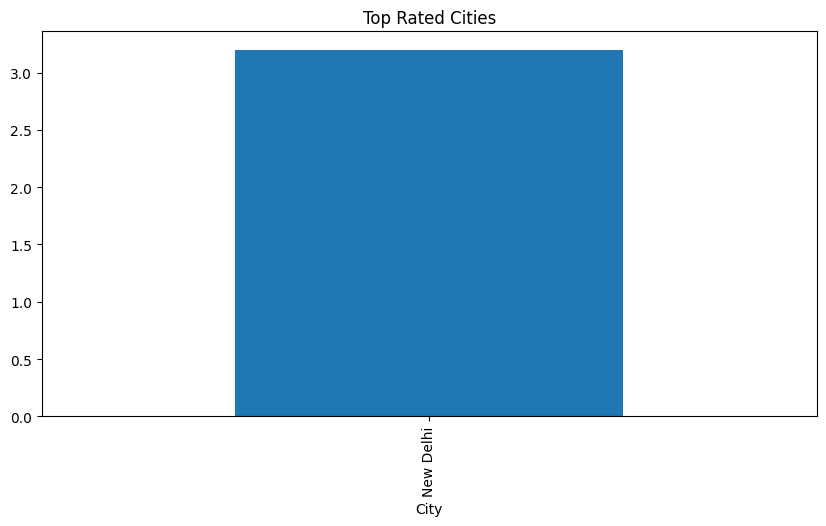

In [37]:
top_city = city_rating.sort_values(
    ascending=False
).head(10)

top_city.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Rated Cities")
plt.show()

In [38]:
#Most Popular Cuisines
top_cuisines = df['Cuisines'].value_counts().head(10)

print(top_cuisines)

Cuisines
North Indian    9551
Name: count, dtype: int64


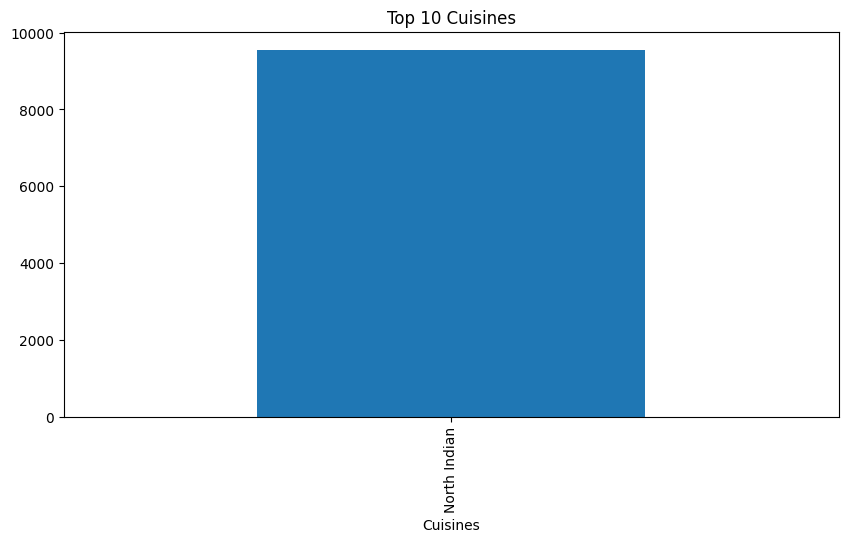

In [39]:
top_cuisines.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Cuisines")
plt.show()

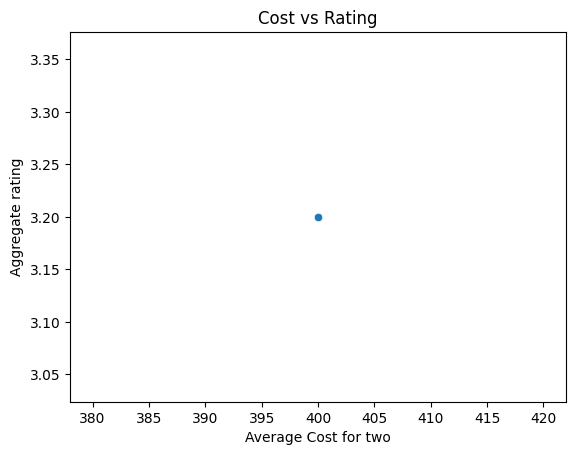

In [40]:
# Cost vs Rating Relationship
sns.scatterplot(
    data=df,
    x='Average Cost for two',
    y='Aggregate rating'
)

plt.title("Cost vs Rating")
plt.show()

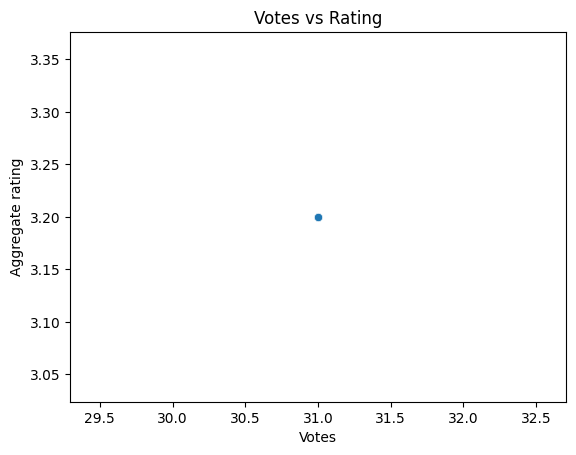

In [41]:
# Votes vs Rating
sns.scatterplot(
    data=df,
    x='Votes',
    y='Aggregate rating'
)

plt.title("Votes vs Rating")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


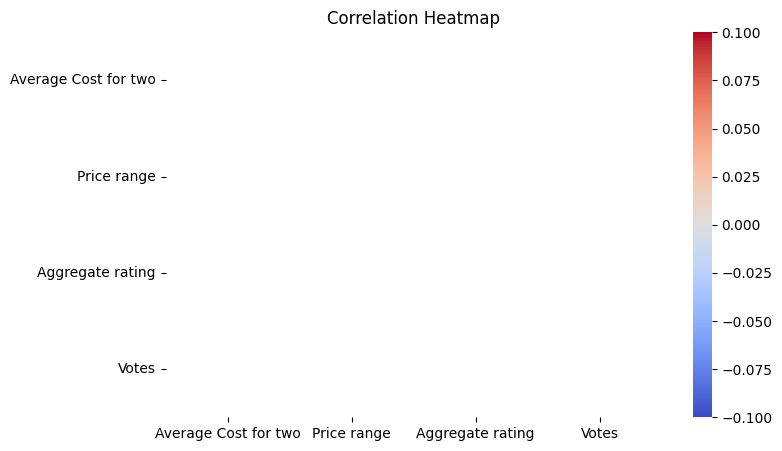

In [42]:
# Correlation Heatmap
numeric_cols = [
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [43]:
# Select Features
features = [
    'Average Cost for two',
    'Price range',
    'Votes',
    'Has Online delivery',
    'Has Table booking'
]

In [44]:
# Encode Categories
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Has Online delivery'] = le.fit_transform(
    df['Has Online delivery']
)

df['Has Table booking'] = le.fit_transform(
    df['Has Table booking']
)

In [45]:
# Prepare X and y
X = df[features]

y = df['Aggregate rating']

In [46]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
# Train Random Forest
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [48]:
# Predictions
y_pred = model.predict(X_test)

In [50]:
# Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.0
MAE: 1.9095836023552692e-13


In [51]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
0  Average Cost for two         0.0
1           Price range         0.0
2                 Votes         0.0
3   Has Online delivery         0.0
4     Has Table booking         0.0


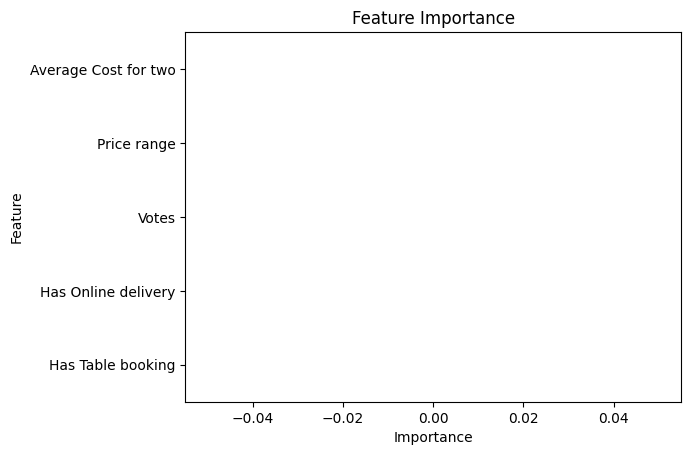

In [52]:
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()